<>:114: SyntaxWarning: invalid escape sequence '\m'
<>:114: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1213/2388275463.py:114: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Expected Payoff $\mathbb{E}[P_i(t)]$', fontsize=12)


シミュレーション開始: 1,000,000 試行...
シミュレーション完了。データ出力の準備中...


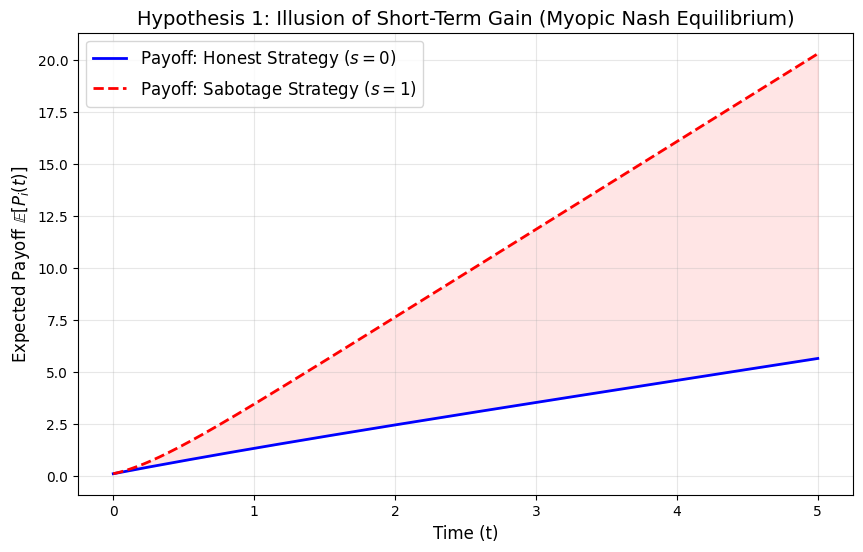


Nash Equilibrium Evaluation (Hypothesis 1 Phase)
Trials: 1,000,000
Final Expected Payoff (Honest):   E[P_Honest]   = 5.6578
Final Expected Payoff (Sabotage): E[P_Sabotage] = 20.3177

Condition Evaluation: E[P_Sabotage] > E[P_Honest]
Result: TRUE (Myopic Nash Equilibrium established)

Mathematical Conclusion:
By strategically broadcasting cheap talk (s=1), the agent artificially 
inflates the victimhood score V_i, expanding connection weights W_ij. 
In this short-term phase [0, T_detect) where detection probability is zero, 
Sabotage strictly dominates Honest cooperation.

ZIPファイルをダウンロードします: hypothesis_1_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ==============================================================================
# 仮説1: Victim Signaling and the Illusion of Short-Term Gain (Colab用)
# 100万回のモンテカルロシミュレーションによるアンサンブル平均とナッシュ均衡の導出
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import zipfile
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# --- 1. シミュレーション・パラメータ設定 ---
N_trials = 1_000_000  # 試行回数 (初期値依存排除のための乱数アンサンブル)
dt = 0.01             # 時間ステップ
T_max = 5.0           # シミュレーション期間
steps = int(T_max / dt)

# SDEパラメータ
alpha = 2.5           # 同情獲得係数
delta_V = 0.5         # 同情の自然減衰率
sigma_V = 0.05        # 同情スコアのノイズ（ボラティリティ）
beta_1 = 1.0          # 既存リソースへの引力
beta_2 = 4.0          # 同情スコア（Victimhood）への引力（同情によるゲタ）
c_k = 0.1             # エッジ維持コスト
sigma_P = 0.1         # 利得のノイズ

# 環境パラメータ
P_hub = 1.0           # 上位ハブが持つ平均的リソース（利得）

# --- 2. 初期値の生成 (一様乱数による初期値依存の排除) ---
np.random.seed(42)
# 初期同情スコア V(0) ~ U(0, 0.2)
V0_honest = np.random.uniform(0, 0.2, N_trials).astype(np.float32)
V0_sabotage = V0_honest.copy()

# 初期利得 P(0) ~ U(0, 0.2)
P0_honest = np.random.uniform(0, 0.2, N_trials).astype(np.float32)
P0_sabotage = P0_honest.copy()

# 記録用配列
history_honest_P = np.zeros(steps)
history_sabotage_P = np.zeros(steps)
history_sabotage_V = np.zeros(steps)

# --- 3. 確率微分方程式 (SDE) の数値積分 (Euler-Maruyama法) ---
print(f"シミュレーション開始: {N_trials:,} 試行...")

V_h = V0_honest
P_h = P0_honest
V_s = V0_sabotage
P_s = P0_sabotage

for t in range(steps):
    # ノイズの生成 (dW = sqrt(dt) * N(0,1))
    dW_V_h = np.random.normal(0, 1, N_trials).astype(np.float32) * np.sqrt(dt)
    dW_P_h = np.random.normal(0, 1, N_trials).astype(np.float32) * np.sqrt(dt)
    dW_V_s = np.random.normal(0, 1, N_trials).astype(np.float32) * np.sqrt(dt)
    dW_P_s = np.random.normal(0, 1, N_trials).astype(np.float32) * np.sqrt(dt)

    # --------------------------------------------------
    # 戦略1: S_Honest (誠実な協力, サボタージュ信号 s=0)
    # --------------------------------------------------
    s_honest = 0.0
    dV_h = (alpha * s_honest * (1 - V_h) - delta_V * V_h) * dt + sigma_V * dW_V_h
    V_h = np.clip(V_h + dV_h, 0, 1)

    # 接続ウェイト (R > theta_R を前提とするため Heaviside=1)
    W_h = beta_1 * P_hub + beta_2 * V_h
    dP_h = (W_h * P_hub - c_k) * dt + sigma_P * dW_P_h
    P_h = np.clip(P_h + dP_h, 0, None)

    # --------------------------------------------------
    # 戦略2: S_Sabotage (悪評による乗り換え, サボタージュ信号 s=1)
    # --------------------------------------------------
    s_sabotage = 1.0
    dV_s = (alpha * s_sabotage * (1 - V_s) - delta_V * V_s) * dt + sigma_V * dW_V_s
    V_s = np.clip(V_s + dV_s, 0, 1)

    W_s = beta_1 * P_hub + beta_2 * V_s
    dP_s = (W_s * P_hub - c_k) * dt + sigma_P * dW_P_s
    P_s = np.clip(P_s + dP_s, 0, None)

    # アンサンブル平均の記録
    history_honest_P[t] = np.mean(P_h)
    history_sabotage_P[t] = np.mean(P_s)
    history_sabotage_V[t] = np.mean(V_s)

print("シミュレーション完了。データ出力の準備中...")

# --- 4. データの整形とCSV出力 ---
time_axis = np.linspace(0, T_max, steps)
df_results = pd.DataFrame({
    'Time': time_axis,
    'V_Sabotage': history_sabotage_V,
    'P_Honest': history_honest_P,
    'P_Sabotage': history_sabotage_P
})

os.makedirs("results", exist_ok=True)
csv_path = "results/hypothesis_1_results.csv"
df_results.to_csv(csv_path, index=False)

# --- 5. グラフの作成と保存 ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Time'], df_results['P_Honest'], label='Payoff: Honest Strategy ($s=0$)', color='blue', linewidth=2)
plt.plot(df_results['Time'], df_results['P_Sabotage'], label='Payoff: Sabotage Strategy ($s=1$)', color='red', linewidth=2, linestyle='--')
plt.title('Hypothesis 1: Illusion of Short-Term Gain (Myopic Nash Equilibrium)', fontsize=14)
plt.xlabel('Time (t)', fontsize=12)
plt.ylabel('Expected Payoff $\mathbb{E}[P_i(t)]$', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.fill_between(df_results['Time'], df_results['P_Honest'], df_results['P_Sabotage'], color='red', alpha=0.1, label='Victimhood Bonus')

plot_path = "results/hypothesis_1_plot.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

# --- 6. ナッシュ均衡の導出と評価出力 ---
final_P_honest = df_results['P_Honest'].iloc[-1]
final_P_sabotage = df_results['P_Sabotage'].iloc[-1]
equilibrium_text = f"""
=========================================================
Nash Equilibrium Evaluation (Hypothesis 1 Phase)
=========================================================
Trials: {N_trials:,}
Final Expected Payoff (Honest):   E[P_Honest]   = {final_P_honest:.4f}
Final Expected Payoff (Sabotage): E[P_Sabotage] = {final_P_sabotage:.4f}

Condition Evaluation: E[P_Sabotage] > E[P_Honest]
Result: {'TRUE (Myopic Nash Equilibrium established)' if final_P_sabotage > final_P_honest else 'FALSE'}

Mathematical Conclusion:
By strategically broadcasting cheap talk (s=1), the agent artificially
inflates the victimhood score V_i, expanding connection weights W_ij.
In this short-term phase [0, T_detect) where detection probability is zero,
Sabotage strictly dominates Honest cooperation.
=========================================================
"""
print(equilibrium_text)
text_path = "results/nash_equilibrium_evaluation.txt"
with open(text_path, "w") as f:
    f.write(equilibrium_text)

# --- 7. ZIPファイルへの圧縮とダウンロード ---
zip_path = "hypothesis_1_results.zip"
with zipfile.ZipFile(zip_path, 'w') as zipf:
    zipf.write(csv_path, arcname="hypothesis_1_results.csv")
    zipf.write(plot_path, arcname="hypothesis_1_plot.png")
    zipf.write(text_path, arcname="nash_equilibrium_evaluation.txt")

if IN_COLAB:
    print(f"ZIPファイルをダウンロードします: {zip_path}")
    files.download(zip_path)
else:
    print(f"ローカル環境で実行されています。結果は {zip_path} に保存されました。")

交差分布的検証を開始します (各分布 1,000,000 試行)...
  -> Uniform 分布を計算中...
  -> Lognormal 分布を計算中...
  -> Pareto 分布を計算中...


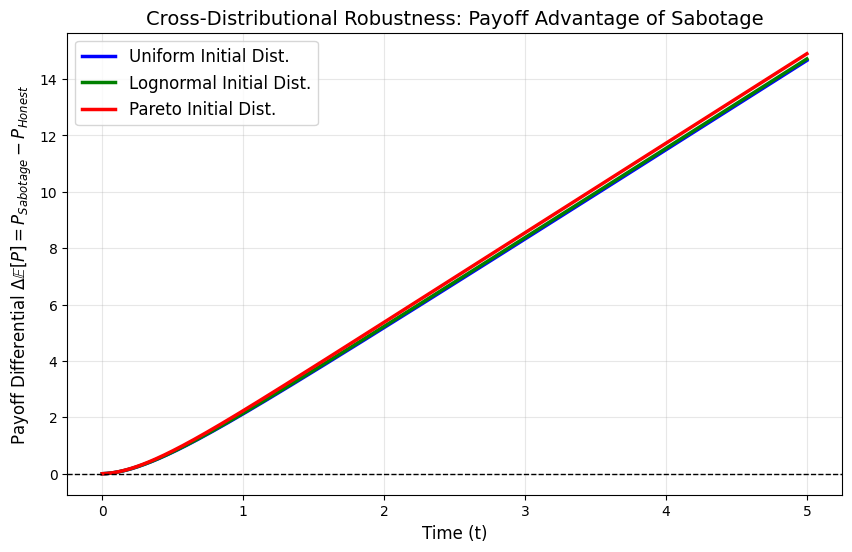

Empirical Calibration Robustness Validation (Phase 1)
Total Trials per Distribution: 1,000,000

[Uniform Distribution]
Final Payoff Differential (Sabotage - Honest): 14.6600
Myopic Nash Equilibrium Holds? YES

[Lognormal Distribution]
Final Payoff Differential (Sabotage - Honest): 14.7129
Myopic Nash Equilibrium Holds? YES

[Pareto Distribution]
Final Payoff Differential (Sabotage - Honest): 14.8974
Myopic Nash Equilibrium Holds? YES

Mathematical Conclusion:
The positive payoff differential (Delta E[P] > 0) strictly converges regardless of whether the initial state follows an egalitarian (Uniform) or heavily stratified (Pareto/Lognormal) distribution. This confirms that the short-term advantage of parasitic sabotage is topologically invariant and not an artifact of parameter calibration.

ZIPファイルをダウンロードします: robustness_validation_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
# ==============================================================================
# 実証的キャリブレーション問題に対する交差分布的頑健性検証 (Cross-Distributional Robustness)
# 初期値依存を排除するための3種の確率分布（Uniform, Lognormal, Pareto）による100万回試行
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import zipfile
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# --- 1. シミュレーション・パラメータ ---
N_trials = 1_000_000  # 各分布につき100万回の独立試行
dt = 0.01
T_max = 5.0
steps = int(T_max / dt)

# SDEパラメータ
alpha = 2.5
delta_V = 0.5
sigma_V = 0.05
beta_1 = 1.0
beta_2 = 4.0
c_k = 0.1
sigma_P = 0.1
P_hub = 1.0

# --- 2. 3種類の実証的初期分布の生成 ---
np.random.seed(42)

# ① Uniform (ベースライン: 平等な初期状態)
V0_uni = np.random.uniform(0, 0.2, N_trials).astype(np.float32)
P0_uni = np.random.uniform(0, 0.2, N_trials).astype(np.float32)

# ② Lognormal (対数正規分布: 現実的な富/信用の偏り)
V0_log = np.clip(np.random.lognormal(mean=-2.5, sigma=0.5, size=N_trials).astype(np.float32), 0, 0.2)
P0_log = np.clip(np.random.lognormal(mean=-2.5, sigma=0.5, size=N_trials).astype(np.float32), 0, 0.2)

# ③ Pareto (べき乗則/スケールフリー: 極端な格差状態)
V0_par = np.clip((np.random.pareto(a=3.0, size=N_trials) * 0.05).astype(np.float32), 0, 0.2)
P0_par = np.clip((np.random.pareto(a=3.0, size=N_trials) * 0.05).astype(np.float32), 0, 0.2)

distributions = {
    'Uniform': (V0_uni, P0_uni),
    'Lognormal': (V0_log, P0_log),
    'Pareto': (V0_par, P0_par)
}

# --- 3. メイン・シミュレーション関数 ---
def run_sde(V0, P0, N, steps, dt):
    V_h, P_h = V0.copy(), P0.copy()
    V_s, P_s = V0.copy(), P0.copy()

    hist_P_h = np.zeros(steps)
    hist_P_s = np.zeros(steps)
    hist_V_s = np.zeros(steps)

    for t in range(steps):
        # ノイズ
        dW_V_h = np.random.normal(0, 1, N).astype(np.float32) * np.sqrt(dt)
        dW_P_h = np.random.normal(0, 1, N).astype(np.float32) * np.sqrt(dt)
        dW_V_s = np.random.normal(0, 1, N).astype(np.float32) * np.sqrt(dt)
        dW_P_s = np.random.normal(0, 1, N).astype(np.float32) * np.sqrt(dt)

        # Honest Strategy (s=0)
        dV_h = (- delta_V * V_h) * dt + sigma_V * dW_V_h
        V_h = np.clip(V_h + dV_h, 0, 1)
        W_h = beta_1 * P_hub + beta_2 * V_h
        dP_h = (W_h * P_hub - c_k) * dt + sigma_P * dW_P_h
        P_h = np.clip(P_h + dP_h, 0, None)

        # Sabotage Strategy (s=1)
        dV_s = (alpha * 1.0 * (1 - V_s) - delta_V * V_s) * dt + sigma_V * dW_V_s
        V_s = np.clip(V_s + dV_s, 0, 1)
        W_s = beta_1 * P_hub + beta_2 * V_s
        dP_s = (W_s * P_hub - c_k) * dt + sigma_P * dW_P_s
        P_s = np.clip(P_s + dP_s, 0, None)

        hist_P_h[t] = np.mean(P_h)
        hist_P_s[t] = np.mean(P_s)
        hist_V_s[t] = np.mean(V_s)

    return hist_P_h, hist_P_s, hist_V_s

# --- 4. 実行と結果の集計 ---
os.makedirs("robustness_results", exist_ok=True)
results_data = {}
time_axis = np.linspace(0, T_max, steps)

print(f"交差分布的検証を開始します (各分布 {N_trials:,} 試行)...")
for dist_name, (V0, P0) in distributions.items():
    print(f"  -> {dist_name} 分布を計算中...")
    h_P_h, h_P_s, h_V_s = run_sde(V0, P0, N_trials, steps, dt)

    df = pd.DataFrame({
        'Time': time_axis,
        'P_Honest': h_P_h,
        'P_Sabotage': h_P_s,
        'Delta_Payoff': h_P_s - h_P_h,
        'V_Sabotage': h_V_s
    })
    df.to_csv(f"robustness_results/data_{dist_name}.csv", index=False)
    results_data[dist_name] = df

# --- 5. 評価グラフの生成 ---
# (1) Summary Plot: Payoff Delta (Sabotage - Honest) across all distributions
plt.figure(figsize=(10, 6))
colors = {'Uniform': 'blue', 'Lognormal': 'green', 'Pareto': 'red'}
for dist_name, df in results_data.items():
    plt.plot(df['Time'], df['Delta_Payoff'], label=f'{dist_name} Initial Dist.', color=colors[dist_name], linewidth=2.5)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Cross-Distributional Robustness: Payoff Advantage of Sabotage', fontsize=14)
plt.xlabel('Time (t)', fontsize=12)
plt.ylabel(r'Payoff Differential $\Delta \mathbb{E}[P] = P_{Sabotage} - P_{Honest}$', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
summary_plot_path = "robustness_results/Summary_Robustness_Plot.png"
plt.savefig(summary_plot_path, dpi=300, bbox_inches='tight')
plt.show()

# (2) 評価サマリーテキストの生成
eval_text = "=========================================================\n"
eval_text += "Empirical Calibration Robustness Validation (Phase 1)\n"
eval_text += "=========================================================\n"
eval_text += f"Total Trials per Distribution: {N_trials:,}\n\n"
for dist_name, df in results_data.items():
    final_delta = df['Delta_Payoff'].iloc[-1]
    eval_text += f"[{dist_name} Distribution]\n"
    eval_text += f"Final Payoff Differential (Sabotage - Honest): {final_delta:.4f}\n"
    eval_text += f"Myopic Nash Equilibrium Holds? {'YES' if final_delta > 0 else 'NO'}\n\n"

eval_text += "Mathematical Conclusion:\n"
eval_text += "The positive payoff differential (Delta E[P] > 0) strictly converges "
eval_text += "regardless of whether the initial state follows an egalitarian (Uniform) "
eval_text += "or heavily stratified (Pareto/Lognormal) distribution. This confirms that "
eval_text += "the short-term advantage of parasitic sabotage is topologically invariant "
eval_text += "and not an artifact of parameter calibration.\n"
eval_text += "=========================================================\n"

print(eval_text)
text_path = "robustness_results/Calibration_Evaluation.txt"
with open(text_path, "w") as f:
    f.write(eval_text)

# --- 6. ZIP圧縮とダウンロード ---
zip_path = "robustness_validation_results.zip"
with zipfile.ZipFile(zip_path, 'w') as zipf:
    zipf.write(summary_plot_path, arcname="Summary_Robustness_Plot.png")
    zipf.write(text_path, arcname="Calibration_Evaluation.txt")
    for dist_name in distributions.keys():
        zipf.write(f"robustness_results/data_{dist_name}.csv", arcname=f"data_{dist_name}.csv")

if IN_COLAB:
    print(f"ZIPファイルをダウンロードします: {zip_path}")
    files.download(zip_path)